### web_search + REPL 을 통해 웹검색 기반으로 차트 생성
langgraph에서 웹검색과 코드시행
1. tavilysearch로 웹검색
2. Python REPL을 통해 local환경 또는 docker환경에서 코드를 실행하느 도구 활용.
local환경에서 사용할경우 사용자의 pc에 위협이되는 코드를 생성하고 실행할수 있기 때문에 이것을 막기위해 human interrupt기능을 사용한다.

- 차트를 그려달라고 또는 시각화 해달라고 요청을 할때, REPL이 유용해진다!

REPL을 로컬환경에서 실행하면, 사용자의 PC에 위협이 될수도 있으므로, interrupt기능을 활용해 사용자로부터 확인을 받도록 만든다.

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

### state 설정

In [2]:
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import SystemMessage, HumanMessage

class State(TypedDict):
    messages: Annotated[list, add_messages]

### 도구 설정(웹 검색, PythongREPL)

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_experimental.utilities import PythonREPL
from langchain_core.tools import tool
from langchain_experimental.chat_models import 
from langchain_community.chat_models import ChatClo

In [ ]:
web_search = TavilySearchResults(max_results=3)
repl = PythonREPL()

#tools을 사용할때는 반드시 주석이 있어야한다. 이것이 description역할을 하는것이다.
@tool
def python_repl(
    code: Annotated[str, "The python code to execute to generate your chart."]
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. chart labels should be written in English.
    This is visible to the user."""
    
    # 파이썬 코드 에러제어 : repr은 객체를 문자열로 반환하는 Python 내장 함수
    try:
        result = repl.run(code) # 코드를 실행할 결과
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}" # 에러가 발생한 이유
    result_str = f"Successfully executed:\n ```python \n{code}```\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )


### 에이전트 도구 인지시키기

In [5]:
tools = [web_search, python_repl]
tool_node = ToolNode(tools)

In [6]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
llm_with_tools = llm.bind_tools(tools)

# node 
# agent함수를 통해서, invoke를 실행한 결과를 만들어준다.
def agent(state: State):
    result = llm_with_tools.invoke(state["messages"])
    return {"messages": [result]}

In [ ]:
# edge - Conditional edge에서 사용할 분기함수.
def should_continue(state):
    messages = state["messages"]
    last_message = messages[-1]
    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"

### 그래프

In [8]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(State)

# node
workflow.add_node("agent", agent)
workflow.add_node("tool", tool_node)

# edge
workflow.add_edge(START,"agent")

workflow.add_conditional_edges(
    "agent",
    
    should_continue,
    {
        "continue": "tool",
        "end": END
    }
)

workflow.add_edge("tool", "agent")

# Set up memory
memory = MemorySaver()

# interrupt_before은 어떤 노드전에 멈출지를 선언하는 것이다.
graph = workflow.compile(checkpointer=memory, interrupt_before=["tool"])

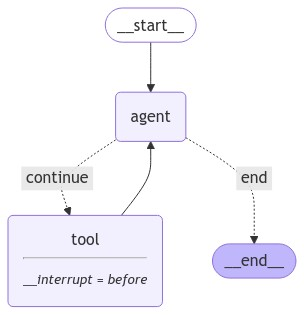

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
initial_input = {"messages": [HumanMessage(content="미국의 최근 5개년(~2023) GDP 차트를 그려줄래?")]}
thread = {"configurable": {"thread_id": "13"}}

# async(어싱크) 함수를 통해 그래프를 실행했을때, 업데이트된 노드만 가져와서 실행하도록 한다.
# stream_mode="updates"를 해줘야, 전체값이 아니라 업데이트 된 값만 가져온다. 
# 그래프의 astream으로  중간 결과값을 저장하게된다.
async for chunk in graph.astream(initial_input,thread, stream_mode="updates"):
    for node, values in chunk.items():
        print(f"Receiving update from node: '{node}'")
        print(values)
        print("\n\n")

# tool_calls를 지날때 멈춘것을 확인할 수 있다.
# Receiving update from node: 'agent' 때문에 tool을 실행하기 전에 멈춘다. 이때는 다시 실행한다.

Receiving update from node: 'agent'
{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_1LrFiycnMXdkih8ggiCP0TpK', 'function': {'arguments': '{"query":"US GDP data for the last 5 years"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 168, 'total_tokens': 194, 'completion_tokens_details': {'audio_tokens': None, 'reasoning_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f59a81427f', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-ee487c66-e464-41d5-aad8-e27d6aa139df-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'US GDP data for the last 5 years'}, 'id': 'call_1LrFiycnMXdkih8ggiCP0TpK', 'type': 'tool_call'}], usage_metadata={'input_tokens': 168, 'output_tokens': 26, 'total_tokens': 194, 'input_token_details': {'ca

In [ ]:
# 그래프가 재실행되게 만들어 준다. thread id를 설정해서 memory saver에 저장되게 만들었다. 
# 따라서 initial_input을 넣어서 재실행하는것이 아니라, 아무것도 넣지않고 astream을한다.
async for chunk in graph.astream(None,thread, stream_mode="updates"):
    for node, values in chunk.items():
        print(f"Receiving update from node: '{node}'")
        print(values)
        print("\n\n")

# Receiving update from node: 'agent' 때문에 tool을 실행하기 전에 멈춘다. 이때는 다시 실행한다.

Receiving update from node: 'tool'
{'messages': [ToolMessage(content='[{"url": "https://fred.stlouisfed.org/series/NGDPRSAXDCUSQ", "content": "Graph and download economic data for Real Gross Domestic Product for United States (NGDPRSAXDCUSQ) from Q1 1950 to Q2 2024 about real, GDP, and USA."}, {"url": "https://www.bea.gov/news/2024/gross-domestic-product-third-estimate-corporate-profits-revised-estimate-and-gdp-0", "content": "Real gross domestic product (GDP) increased at an annual rate of 3.0 percent in the second quarter of 2024 (table 1), according to the \\"third\\" estimate released by the U.S. Bureau of Economic Analysis. The average of real GDP and real GDI, a supplemental measure of U.S. economic activity that equally weights GDP and GDI, increased 3.2 percent in the second quarter, an upward revision of 1.1 percentage points from the previous estimate (table 1). For the period of economic expansion from the second quarter of 2009 through the fourth quarter of 2019, real GDP i

Python REPL can execute arbitrary code. Use with caution.


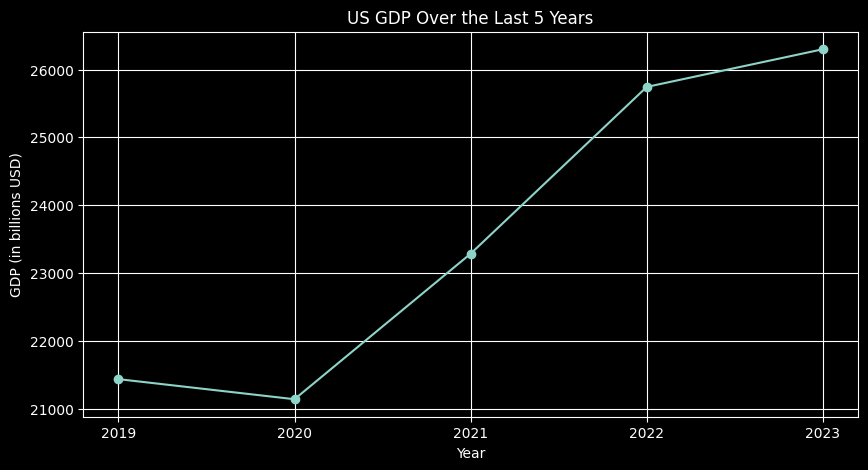

Receiving update from node: 'tool'
{'messages': [ToolMessage(content="Successfully executed:\n ```python \nimport matplotlib.pyplot as plt\nimport numpy as np\n\n# GDP data for the last 5 years (in billions USD)\nyears = np.array([2019, 2020, 2021, 2022, 2023])\ngdp_values = np.array([21433.23, 21137.00, 23284.00, 25744.11, 26300.00])  # Estimated for 2023\n\nplt.figure(figsize=(10, 5))\nplt.plot(years, gdp_values, marker='o')\nplt.title('US GDP Over the Last 5 Years')\nplt.xlabel('Year')\nplt.ylabel('GDP (in billions USD)')\nplt.xticks(years)\nplt.grid(True)\nplt.show()```\nStdout: \n\nIf you have completed all tasks, respond with FINAL ANSWER.", name='python_repl', id='80cd1eef-a7c1-450d-852c-505e2a8a4cad', tool_call_id='call_YHI9nYYi2Kv0Xl08OH9JsYxI')]}



Receiving update from node: 'agent'
{'messages': [AIMessage(content='Here is the chart showing the US GDP over the last 5 years:\n\n![US GDP Over the Last 5 Years](attachment://gdp_chart.png)\n\n- **2019**: $21,433.23 billion\n- *

In [12]:
async for chunk in graph.astream(None,thread, stream_mode="updates"):
    for node, values in chunk.items():
        print(f"Receiving update from node: '{node}'")
        print(values)
        print("\n\n")

In [13]:
initial_input = {"messages": [HumanMessage(content="대한민국의 최근 5개년(~2023) GDP 차트를 그려줄래?")]}
thread = {"configurable": {"thread_id": "13"}}

# stream_mode="updates"를 해줘야, 전체값이 아니라 업데이트 된 값만 가져온다.
async for chunk in graph.astream(initial_input,thread, stream_mode="updates"):
    for node, values in chunk.items():
        print(f"Receiving update from node: '{node}'")
        print(values)
        print("\n\n")

# tool_calls를 지날때 멈춘것을 확인할 수 있다.

Receiving update from node: 'agent'
{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_OolBTBOMZ6T0FPU7ukFkSuCW', 'function': {'arguments': '{"query":"South Korea GDP data for the last 5 years"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1148, 'total_tokens': 1175, 'completion_tokens_details': {'audio_tokens': None, 'reasoning_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1024}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f59a81427f', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-bf18a2ef-4b0b-4bd9-9aa7-4f3422e4ec38-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'South Korea GDP data for the last 5 years'}, 'id': 'call_OolBTBOMZ6T0FPU7ukFkSuCW', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1148, 'output_tokens': 27, 'total_tokens': 1175, 'i

In [14]:
async for chunk in graph.astream(None,thread, stream_mode="updates"):
    for node, values in chunk.items():
        print(f"Receiving update from node: '{node}'")
        print(values)
        print("\n\n")

Receiving update from node: 'tool'
{'messages': [ToolMessage(content='[{"url": "https://tradingeconomics.com/south-korea/gdp", "content": "The Gross Domestic Product (GDP) in South Korea was worth 1712.79 billion US dollars in 2023, according to official data from the World Bank. The GDP value of South Korea represents 1.62 percent of the world economy. This page provides - South Korea GDP - actual values, historical data, forecast, chart, statistics, economic calendar and news."}, {"url": "https://tradingeconomics.com/south-korea/gdp-growth-annual", "content": "The Gross Domestic Product (GDP) in South Korea expanded 2.30 percent in the second quarter of 2024 over the same quarter of the previous year. GDP Annual Growth Rate in South Korea averaged 6.92 percent from 1961 until 2024, reaching an all time high of 20.80 percent in the fourth quarter of 1969 and a record low of -7.30 percent in the second"}, {"url": "https://www.macrotrends.net/global-metrics/countries/KOR/south-korea/gdp

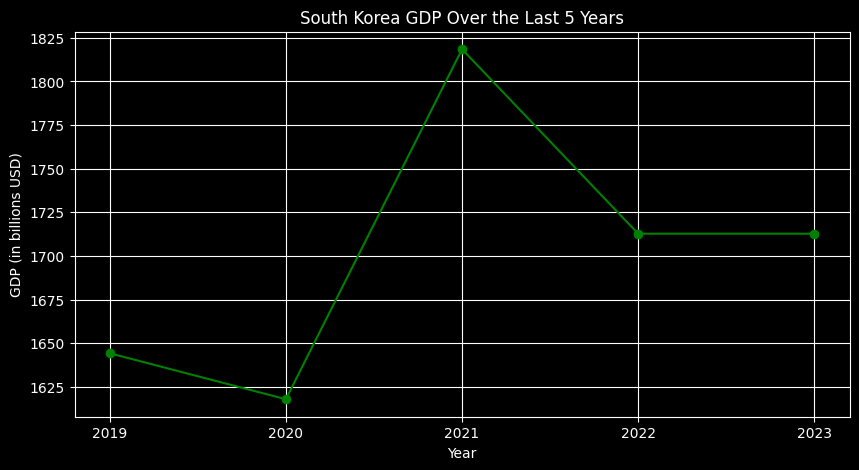

Receiving update from node: 'tool'
{'messages': [ToolMessage(content="Successfully executed:\n ```python \nimport matplotlib.pyplot as plt\nimport numpy as np\n\n# GDP data for South Korea for the last 5 years (in billions USD)\nyears = np.array([2019, 2020, 2021, 2022, 2023])\ngdp_values = np.array([1644.31, 1618.00, 1818.43, 1712.79, 1712.79])  # Estimated for 2023\n\nplt.figure(figsize=(10, 5))\nplt.plot(years, gdp_values, marker='o', color='green')\nplt.title('South Korea GDP Over the Last 5 Years')\nplt.xlabel('Year')\nplt.ylabel('GDP (in billions USD)')\nplt.xticks(years)\nplt.grid(True)\nplt.show()```\nStdout: \n\nIf you have completed all tasks, respond with FINAL ANSWER.", name='python_repl', id='df3315f8-ecb4-4502-91ab-265938aeef4a', tool_call_id='call_rpCQjbxcETfLWXazv92yfFmu')]}



Receiving update from node: 'agent'
{'messages': [AIMessage(content="Here is the chart showing South Korea's GDP over the last 5 years:\n\n- **2019**: $1,644.31 billion\n- **2020**: $1,618.00 bil

In [15]:
async for chunk in graph.astream(None,thread, stream_mode="updates"):
    for node, values in chunk.items():
        print(f"Receiving update from node: '{node}'")
        print(values)
        print("\n\n")